In [15]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 多智能体研究系统

本notebook将之前的所有组件合并到一个系统中。

这是我们的整体研究流程：

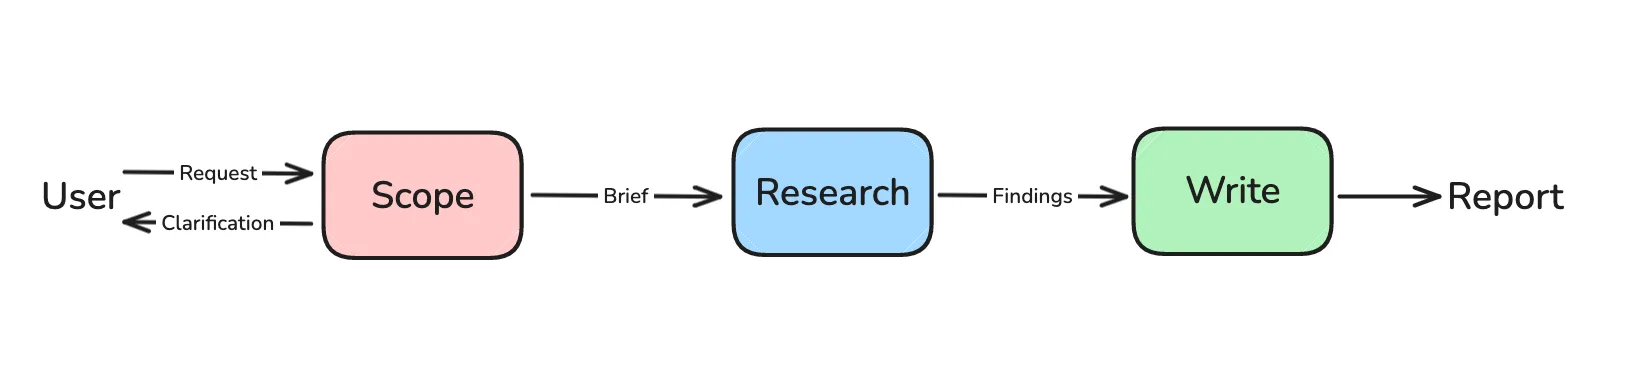

我们已经在之前的notebook中构建了研究范围界定和多智能体研究。

现在，我们将添加最终报告生成步骤。

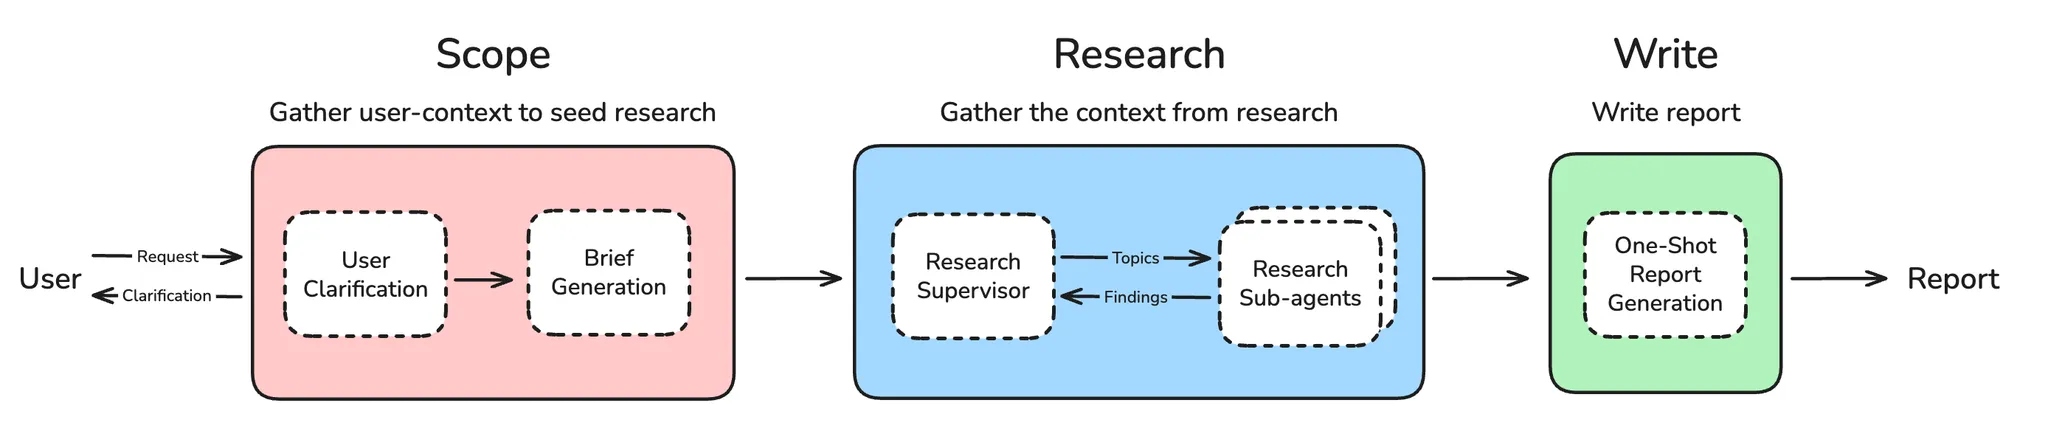

### 智能体

我们可以简单地重用已经构建的组件。

In [ ]:
%%writefile ../src/deep_research_from_scratch/research_agent_full.py

"""
完整的多智能体研究系统

此模块集成了研究系统的所有组件：
- 用户澄清和范围界定
- 研究简报生成
- 多智能体研究协调
- 最终报告生成

该系统协调从初始用户输入到最终报告交付的完整研究工作流程。
"""

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END

from deep_research_from_scratch.utils import get_today_str
from deep_research_from_scratch.prompts import final_report_generation_prompt
from deep_research_from_scratch.state_scope import AgentState, AgentInputState
from deep_research_from_scratch.research_agent_scope import clarify_with_user, write_research_brief
from deep_research_from_scratch.multi_agent_supervisor import supervisor_agent

# ===== 配置 =====

from langchain.chat_models import init_chat_model
writer_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== 最终报告生成 =====

from deep_research_from_scratch.state_scope import AgentState

async def final_report_generation(state: AgentState):
    """
    最终报告生成节点。

    将所有研究发现综合为一份全面的最终报告
    """
    
    notes = state.get("notes", [])
    
    findings = "\n".join(notes)

    final_report_prompt = final_report_generation_prompt.format(
        research_brief=state.get("research_brief", ""),
        findings=findings,
        date=get_today_str()
    )
    
    final_report = await writer_model.ainvoke([HumanMessage(content=final_report_prompt)])
    
    return {
        "final_report": final_report.content, 
        "messages": ["Here is the final report: " + final_report.content],
    }

# ===== 图构建 =====
# 构建整体工作流程
deep_researcher_builder = StateGraph(AgentState, input_schema=AgentInputState)

# 添加工作流程节点
deep_researcher_builder.add_node("clarify_with_user", clarify_with_user)
deep_researcher_builder.add_node("write_research_brief", write_research_brief)
deep_researcher_builder.add_node("supervisor_subgraph", supervisor_agent)
deep_researcher_builder.add_node("final_report_generation", final_report_generation)

# 添加工作流程边
deep_researcher_builder.add_edge(START, "clarify_with_user")
deep_researcher_builder.add_edge("write_research_brief", "supervisor_subgraph")
deep_researcher_builder.add_edge("supervisor_subgraph", "final_report_generation")
deep_researcher_builder.add_edge("final_report_generation", END)

# 编译完整工作流程
agent = deep_researcher_builder.compile()

In [ ]:
# 运行工作流程
from utils import format_messages
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research_from_scratch.research_agent_full import deep_researcher_builder

checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

LangGraph 有一个默认的25步递归限制以防止无限循环。对于需要多轮迭代研究的复杂研究工作流程，需要增加这个限制。如 [LangGraph 故障排除指南](https://langchain-ai.github.io/langgraph/troubleshooting/errors/GRAPH_RECURSION_LIMIT/) 中所解释的，递归限制会计算图中的每个节点执行。在我们的多智能体研究系统中：

- **单个研究智能体**：工具调用和压缩可能需要8-12步
- **多智能体监督器**：每个产生的子智能体都会增加额外的步骤
- **迭代研究**：监督器可能进行多轮研究以填补空白
- **完整工作流程**：包括范围界定、研究简报生成、监督和报告生成

我们将递归限制设置为 **50** 以适应：
- 需要多轮研究的复杂研究主题
- 并行子智能体执行
- 具有许多工具调用的深度研究
- 从范围界定到最终报告的完整工作流程执行

这允许监督器在初始发现有空白时进行迭代研究，确保对复杂研究主题的全面覆盖。

In [3]:
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Compare Gemini to OpenAI Deep Research agents.")]}, config=thread)
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'OpenAI Deep Research agents'? Are you referring to a specific product,      │
│ research project, or a general class of AI agents developed by OpenAI?                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
result = await full_agent.ainvoke({"messages": [HumanMessage(content="Yes the specific Deep Research products.")]}, config=thread)

In [5]:
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Compare Gemini to OpenAI Deep Research agents.                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Could you clarify what you mean by 'OpenAI Deep Research agents'? Are you referring to a specific product,      │
│ research project, or a general class of AI agents developed by OpenAI?                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Yes the specific Deep Research products.                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Thank you for clarifying that you are referring to the specific Deep Research products from OpenAI. I           │
│ understand that you would like a comparison between Gemini and OpenAI's Deep Research agents. I will now begin  │
│ the research and prepare a comparative analysis based on the information provided.                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Here is the final report: # Comprehensive Comparison: Google Gemini vs. OpenAI Deep Research Agents (2025)      │
│                                                                                                                 │
│ ## Introduction                                                                                                 │
│                                                                                                                 │
│ This report provides a detailed, balanced comparison of Google’s Gemini AI suite and OpenAI’s Deep Research     │
│ agents. Both technologies represent state-of-the-art advancements in artificial intelligence but are designed   │
│ with distinct architectures, capabilities, use cases, and integration models. This analysis examines key        │
│ aspects such as core features, intended applications, underlying technologies, performance benchmarks,          │
│ integration options, and notable strengths and weaknesses, referencing the latest information and official      │
│ documentation as of August 2025.                                                                                │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Overview: Google Gemini                                                                                      │
│                                                                                                                 │
│ ### Core Capabilities                                                                                           │
│                                                                                                                 │
│ - **Multimodality**: Gemini supports native processing of text, images, video, audio, code, and PDF inputs, and │
│ can generate outputs in text, audio, and structured data formats. Recent iterations, such as Gemini 2.5 Deep    │
│ Think, can handle context windows exceeding 1 million tokens and output up to 192,000 tokens, enabling the      │
│ processing of vast and complex documents or media streams.                                                      │
│ - **Advanced Reasoning**: The “Deep Think” and Pro variants deploy parallel hypothesis testing and              │
│ reinforcement learning, excelling at coding, complex mathematical reasoning, multimodal understanding,          │
│ structured outputs, and function/tool calling.                                                                  │
│ - **Agentic Capabilities**: Gemini powers research agents and universal AI assistants (e.g., Project Astra,     │
│ Project Mariner), handling autonomous workflows like code debugging, real-time information retrieval, and       │
│ interactive web task completion.                                                                                │
│ - **Safety and Governance**: Gemini employs extensive safety measures, including red teaming (automated and     │
│ external), multi-tiered abuse monitoring, mitigations against sensitive domains (e.g., chemical/biological),    │
│ and oversight by Google DeepMind’s Responsibility and Safety Council. It adheres to ethical principles such as  │
│ minimization of bias and toxicity.                                                                              │
│                                                                                                                 │
│ ### Intended Use Cases                                                                                          │
│                                                        

In [6]:
from rich.markdown import Markdown
Markdown(result["final_report"])

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                 Comprehensive Comparison: Google Gemini vs. OpenAI Deep Research Agents (2025)                  ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛


                                                   Introduction                                                    

This report provides a detailed, balanced comparison of Google’s Gemini AI suite and OpenAI’s Deep Research agents.
Both technologies represent state-of-the-art advancements in artificial intelligence but are designed with distinct
architectures, capabilities, use cases, and integration models. This analysis examines key aspects such as core    
features, intended applications, underlying technologies, performance benchmarks, integration options, and notable 
strengths and weaknesses, referencing the latest information and official documentation as of August 2025.         

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                              Overview: Google Gemini                                              

                                                 Core Capabilities                                                 

 • Multimodality: Gemini supports native processing of text, images, video, audio, code, and PDF inputs, and can   
   generate outputs in text, audio, and structured data formats. Recent iterations, such as Gemini 2.5 Deep Think, 
   can handle context windows exceeding 1 million tokens and output up to 192,000 tokens, enabling the processing  
   of vast and complex documents or media streams.                                                                 
 • Advanced Reasoning: The “Deep Think” and Pro variants deploy parallel hypothesis testing and reinforcement      
   learning, excelling at coding, complex mathematical reasoning, multimodal understanding, structured outputs, and
   function/tool calling.                                                                                          
 • Agentic Capabilities: Gemini powers research agents and universal AI assistants (e.g., Project Astra, Project   
   Mariner), handling autonomous workflows like code debugging, real-time information retrieval, and interactive   
   web task completion.                                                                                            
 • Safety and Governance: Gemini employs extensive safety measures, including red teaming (automated and external),
   multi-tiered abuse monitoring, mitigations against sensitive domains (e.g., chemical/biological), and oversight 
   by Google DeepMind’s Responsibility and Safety Council. It adheres to ethical principles such as minimization of
   bias and toxicity.                                                                                              

                                                Intended Use Cases                                                 

 • Complex knowledge work (e.g., scientific research, coding assistants, market analysis)                          
 • Large-scale document analysis, summarization, and synthesis                                                     
 • Content creation across text, image, video (e.g., AI-powered design, video generation with Veo, music with      
   Lyria)                                                                                                          
 • Autonomous agents for enterprise workflows (e.g., web research, spreadsheet automation, technical support,      
   creative design)                                                                                                
 • Integration into Google products and services: Workspace (Docs, Sheets, Slides), Pixel devices, Search, Ads,    
   Chrome, and Duet AI                         

我们可以在 [这里](https://smith.langchain.com/public/86ebdc25-4595-4040-be1e-a8e30052786b/r) 查看追踪。

### LangGraph Studio

就像我们之前做的一样，我们也可以使用 LangGraph Studio 来可视化智能体。

我们在所有notebook中使用 `%%writefile` 写入到 `src/deep_research_from_scratch/` 的文件为我们的应用程序创建了文件：

```
deep_research_from_scratch/
├── src/deep_research_from_scratch/
│   ├── state.py          # 状态定义
│   ├── scope_research.py # 范围界定工作流程
│   ├── prompts.py        # 提示模板
│   └── ...
├── notebooks/            # 开发notebook
├── pyproject.toml        # 依赖项
└── langgraph.json        # LangGraph配置
```

此智能体已添加到 `langgraph.json` 文件中，因此您可以在下拉菜单中选择 `research_agent_full`：

```
"research_agent_full": "./src/deep_research_from_scratch/research_agent_full.py:agent"
```

运行以下命令启动studio

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev --allow-blocking
```